# 30-Day Patient Readmission Prediction
## End-to-End Deep Learning Pipeline

This notebook covers the full pipeline:
1. Data Loading & Initial Inspection
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Outlier Handling
4. Feature Engineering
5. Missing Value Handling
6. Class Imbalance Analysis
7. Encoding & Scaling
8. SMOTE Oversampling
9. Model Training (PyTorch Neural Network)
10. Evaluation & Threshold Tuning
11. Test Set Predictions

## 1. Imports & Setup

In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, precision_recall_curve,
    roc_curve, precision_score, recall_score
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Settings
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print("All imports successful!")

All imports successful!


## 2. Load Raw Data

In [2]:
# Load raw datasets
train_df = pd.read_csv("data/train.csv")
test_df  = pd.read_csv("data/test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
display(train_df.head())
display(test_df.head())

Train shape: (3800, 18)
Test shape:  (950, 17)


,patient_id,admission_date,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl,readmitted_30d
0,PID10000,2020-01-01,24.0,M,1,1,Tue,1.8,7.0,6.0,2,Private,100.4,112.30,132.5,0.82,10.3,0
1,PID10001,01/01/2020,73.0,F,1,1,Thu,14.7,2.0,2.0,14,Medicaid,114.3,166.10,154.3,1.32,10.6,0
2,PID10002,01/01/2020,65.0,F,1,3,Wed,10.6,0.0,0.0,3,Private,106.4,17.69,133.8,1.08,13.6,0
3,PID10003,2020-01-01,49.0,M,2,1,Fri,9.1,0.0,0.0,9,Medicaid,97.4,131.90,149.8,0.64,13.5,0
4,PID10004,2020-01-02,49.0,F,1,1,Thu,7.5,0.0,0.0,7,Medicare,NaN,137.30,142.4,2.26,11.9,0


,patient_id,admission_date,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl
0,PID10000,2020-01-01,89.0,F,2,1,Sun,12.2,1.0,1.0,15,Medicare,64.1,120.3,138.3,1.57,10.5
1,PID10001,2020-01-01,85.0,M,2,2,Thu,8.1,0.0,1.0,5,Uninsured,142.4,130.4,138.5,1.03,11.1
2,PID10002,01/01/2020,55.0,F,1,3,Wed,1.7,2.0,1.0,12,Medicaid,109.9,130.8,142.8,1.30,11.1
3,PID10003,2020-01-01,66.0,F,1,1,Sun,20.5,2.0,2.0,7,Medicare,136.5,102.4,138.8,1.21,13.7
4,PID10004,02/01/2020,70.0,M,1,3,Wed,4.4,1.0,0.0,17,Medicare,60.0,140.8,130.6,0.71,14.1


In [3]:
# Data types and basic info
print("Train Info:")
train_df.info()
print("Test Info:")
test_df.info()

Train Info:
<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  3800 non-null   str    
 1   admission_date              3800 non-null   str    
 2   age                         3800 non-null   float64
 3   gender                      3800 non-null   str    
 4   admission_type              3800 non-null   int64  
 5   discharge_destination       3800 non-null   int64  
 6   discharge_day_of_week       3800 non-null   str    
 7   length_of_stay_days         3800 non-null   float64
 8   charlson_comorbidity_index  3800 non-null   float64
 9   prior_admissions_1yr        3800 non-null   float64
 10  n_medications_discharge     3800 non-null   int64  
 11  insurance_type              3800 non-null   str    
 12  glucose_level_mgdl          3127 non-null   float64
 13  blood_pressure_systolic     3800

In [4]:
# Statistical summary
display(train_df.describe())
display(train_df.describe(include="object"))

,age,admission_type,discharge_destination,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl,readmitted_30d
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3127.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,56.566842,1.542105,1.656579,7.247921,2.268421,2.152105,9.699737,104.443780,114.079995,137.855211,1.199868,12.471132,0.090000
std,56.968099,0.658486,0.923051,4.816102,2.271643,2.133976,5.768190,26.450105,40.952359,3.992365,0.500145,1.975551,0.286219
min,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,60.000000,10.670000,125.000000,0.400000,6.000000,0.000000
25%,35.000000,1.000000,1.000000,4.000000,1.000000,0.000000,5.000000,85.100000,106.300000,135.100000,0.860000,11.100000,0.000000
50%,53.000000,1.000000,1.000000,6.000000,2.000000,2.000000,10.000000,103.600000,124.200000,137.700000,1.110000,12.500000,0.000000
75%,72.000000,2.000000,2.000000,9.100000,3.000000,3.000000,15.000000,122.400000,138.800000,140.500000,1.430000,13.800000,0.000000
max,999.000000,3.000000,4.000000,45.100000,10.000000,11.000000,19.000000,188.000000,209.800000,154.300000,4.910000,18.000000,1.000000


,patient_id,admission_date,gender,discharge_day_of_week,insurance_type
count,3800,3800,3800,3800,3800
unique,3800,1755,2,7,4
top,PID10000,2020-01-08,M,Fri,Medicare
freq,1,4,1935,571,1435


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution (Class Imbalance)

Target Distribution:
readmitted_30d
0    3458
1     342
Name: count, dtype: int64
Positive class ratio: 0.0900 (9.0%)
Imbalance ratio: 10.1:1


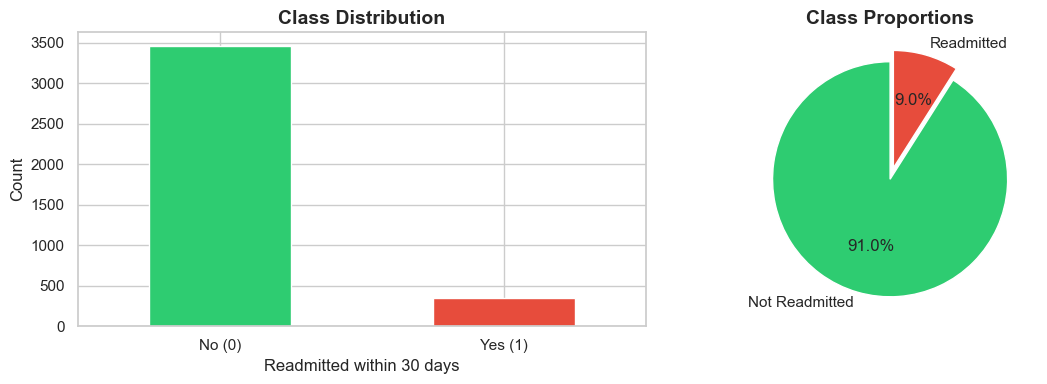

SEVERE CLASS IMBALANCE: Only ~9.0% positive class.


In [8]:
target_counts = train_df["readmitted_30d"].value_counts()
target_ratio  = train_df["readmitted_30d"].mean()

print("Target Distribution:")
print(target_counts)
print(f"Positive class ratio: {target_ratio:.4f} ({target_ratio*100:.1f}%)")
print(f"Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Readmitted within 30 days")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
axes[1].pie(target_counts, labels=["Not Readmitted", "Readmitted"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, explode=(0, 0.1))
axes[1].set_title("Class Proportions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"SEVERE CLASS IMBALANCE: Only ~{target_ratio*100:.1f}% positive class.")

### 3.2 Numeric Feature Distributions

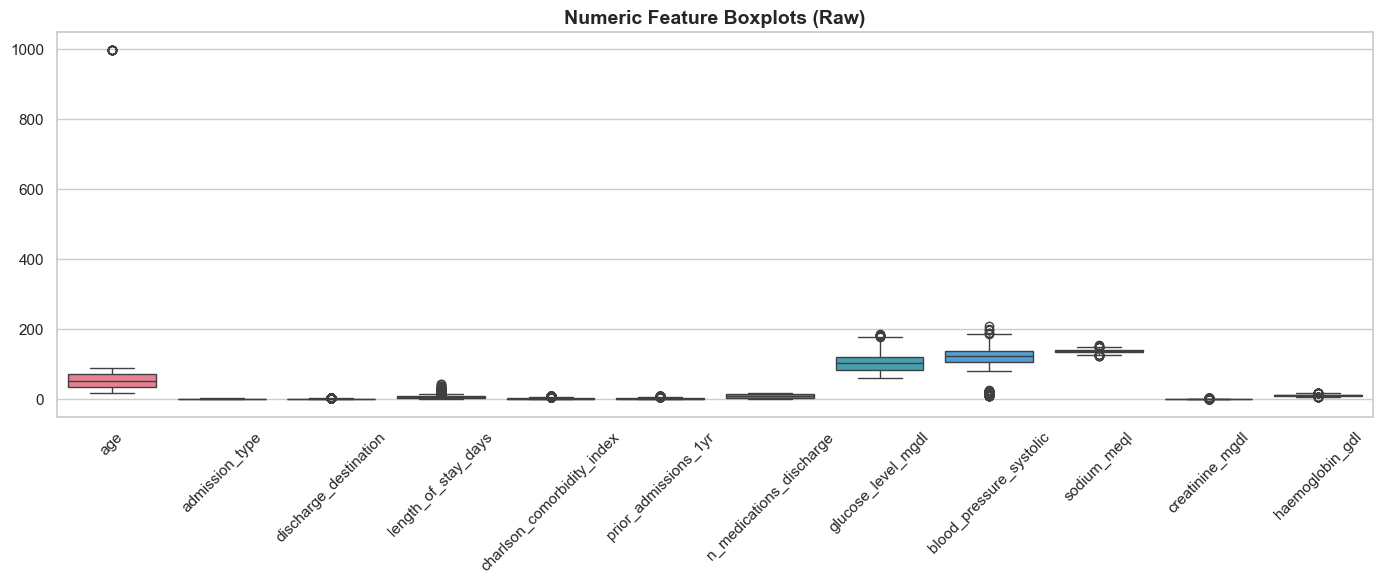

In [9]:
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "readmitted_30d" in num_cols:
    num_cols.remove("readmitted_30d")

plt.figure(figsize=(14, 6))
sns.boxplot(data=train_df[num_cols])
plt.title("Numeric Feature Boxplots (Raw)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

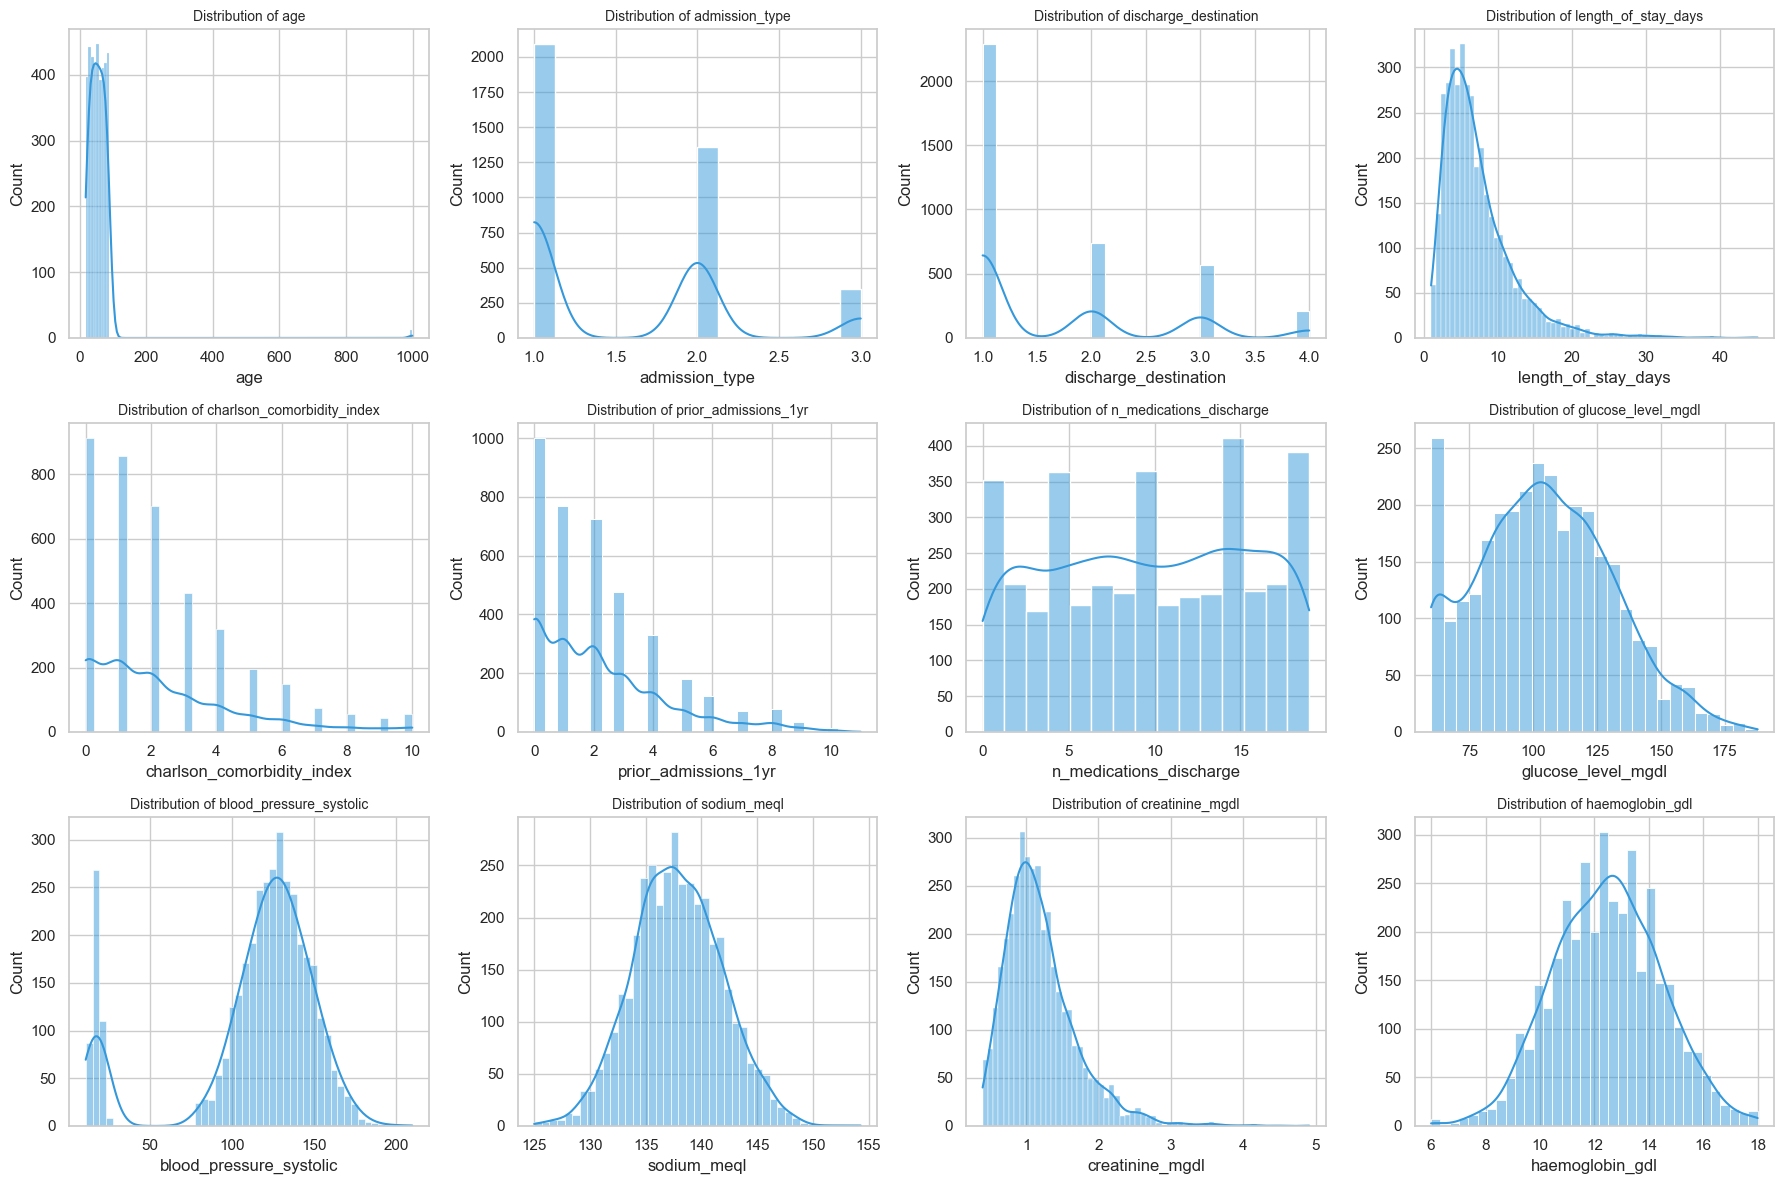

In [10]:
# Distribution histograms for each numeric feature
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols[:12]):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color="#3498db")
    axes[i].set_title(f"Distribution of {col}", fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### 3.3 Categorical Feature Analysis

Categorical columns: ['patient_id', 'admission_date', 'gender', 'discharge_day_of_week', 'insurance_type']


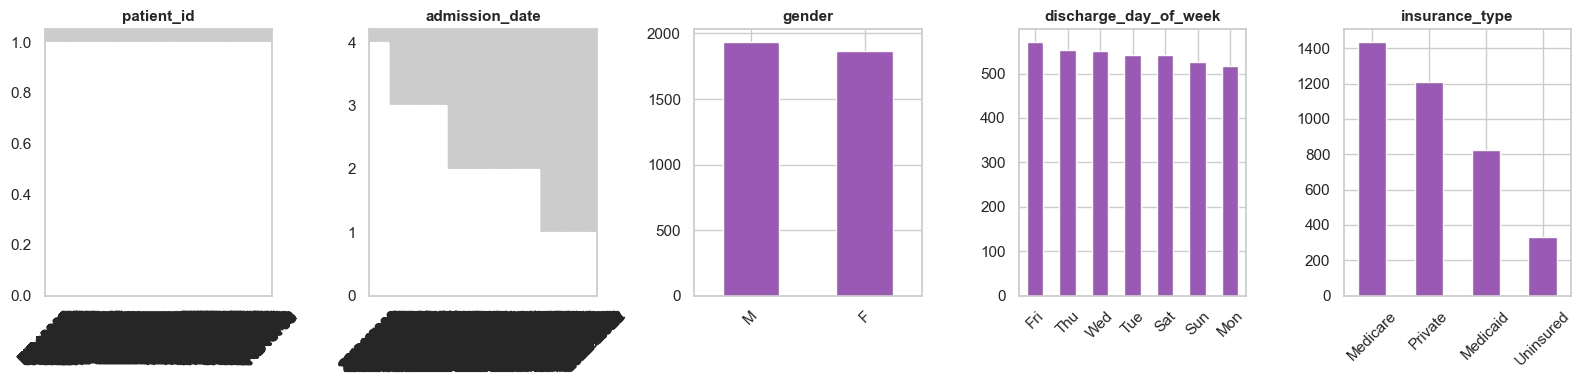

In [11]:
cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))
for i, col in enumerate(cat_cols):
    ax = axes[i] if len(cat_cols) > 1 else axes
    vc = train_df[col].value_counts()
    vc.plot(kind="bar", ax=ax, color="#9b59b6")
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Feature Correlation with Target

In [13]:
# Mean readmission rate by category
for col in cat_cols:
    print(f"Readmission rate by {col}:")
    print(train_df.groupby(col)["readmitted_30d"].mean().sort_values(ascending=False))

Readmission rate by patient_id:
patient_id
PID13230    1.0
PID13239    1.0
PID11475    1.0
PID10613    1.0
PID13247    1.0
           ... 
PID11340    0.0
PID11341    0.0
PID11342    0.0
PID11343    0.0
PID11326    0.0
Name: readmitted_30d, Length: 3800, dtype: float64
Readmission rate by admission_date:
admission_date
01/03/2022    1.0
26/05/2020    1.0
11/01/2021    1.0
29/12/2021    1.0
29/06/2022    1.0
             ... 
2020-08-24    0.0
2020-07-22    0.0
2020-07-23    0.0
2020-07-25    0.0
07/10/2020    0.0
Name: readmitted_30d, Length: 1755, dtype: float64
Readmission rate by gender:
gender
M    0.090439
F    0.089544
Name: readmitted_30d, dtype: float64
Readmission rate by discharge_day_of_week:
discharge_day_of_week
Mon    0.108527
Wed    0.094545
Thu    0.088608
Sat    0.088561
Sun    0.087452
Tue    0.083026
Fri    0.080560
Name: readmitted_30d, dtype: float64
Readmission rate by insurance_type:
insurance_type
Uninsured    0.103030
Medicaid     0.095642
Private      0.086849

### 3.5 Missing Values

Missing Values:


,count,percent
glucose_level_mgdl,673,17.71


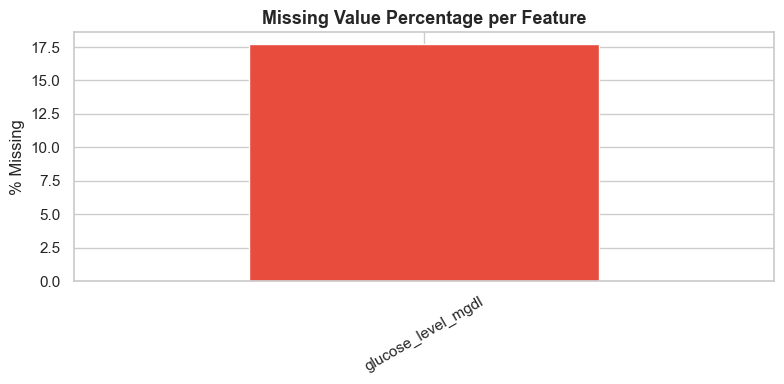

In [14]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df)) * 100

print("Missing Values:")
display(pd.DataFrame({"count": missing, "percent": missing_pct.round(2)}))

plt.figure(figsize=(8, 4))
missing_pct.plot(kind="bar", color="#e74c3c")
plt.title("Missing Value Percentage per Feature", fontsize=13, fontweight="bold")
plt.ylabel("% Missing")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [29]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [39]:
# ---- Step 4b: Impute missing values ----
# Use TRAIN medians to fill both train and test (prevent data leakage)

age_median = train_df['age'].median()
glucose_median = train_df['glucose_level_mgdl'].median()

print(f'Imputation values (from train):')
print(f'  age median:     {age_median}')
print(f'  glucose median: {glucose_median}')

# Train
train_df['age'] = train_df['age'].fillna(age_median)
train_df['glucose_level_mgdl'] = train_df['glucose_level_mgdl'].fillna(glucose_median)

# Test
test_df['age'] = test_df['age'].fillna(age_median)
test_df['glucose_level_mgdl'] = test_df['glucose_level_mgdl'].fillna(glucose_median)

print(f'\nRemaining NaNs in train: {train_df.isnull().sum().sum()}')
print(f'Remaining NaNs in test:  {test_df.isnull().sum().sum()}')

Imputation values (from train):
  age median:     53.0
  glucose median: 103.6

Remaining NaNs in train: 0
Remaining NaNs in test:  0


## 4. Data Cleaning & Preprocessing

All preprocessing is applied identically to train and test to prevent data leakage.

### 4.1 Drop Irrelevant Columns

In [40]:
# Drop patient_id - not a predictive feature
train_df.drop(columns=["patient_id"], inplace=True, errors="ignore")
test_df.drop(columns=["patient_id"], inplace=True, errors="ignore")
print(f"Train shape after dropping patient_id: {train_df.shape}")

Train shape after dropping patient_id: (3800, 29)


### 4.2 Outlier Handling – Age

In [41]:
# Age = 999 is clearly a sentinel/error value → replace with NaN
outlier_count = (train_df["age"] == 999).sum()
print(f"Age = 999 outliers in train: {outlier_count}")

train_df["age"] = train_df["age"].replace(999, np.nan)
test_df["age"]  = test_df["age"].replace(999, np.nan)
print("✅ Age outliers (999) replaced with NaN")

Age = 999 outliers in train: 0
✅ Age outliers (999) replaced with NaN


### 4.3 Outlier Handling – Blood Pressure (Unit Fix)

BP values < 50 in train: 0
BP values < 50 in test:  0


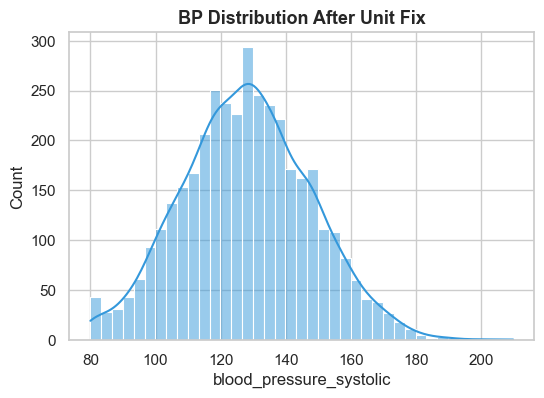

In [42]:
# Some BP values < 50 are likely recorded in kPa instead of mmHg
low_bp_train = (train_df["blood_pressure_systolic"] < 50).sum()
low_bp_test  = (test_df["blood_pressure_systolic"] < 50).sum()
print(f"BP values < 50 in train: {low_bp_train}")
print(f"BP values < 50 in test:  {low_bp_test}")

# Convert kPa → mmHg (multiply by 7.50062)
mask_train = train_df["blood_pressure_systolic"] < 50
train_df.loc[mask_train, "blood_pressure_systolic"] *= 7.50062

mask_test = test_df["blood_pressure_systolic"] < 50
test_df.loc[mask_test, "blood_pressure_systolic"] *= 7.50062

plt.figure(figsize=(6, 4))
sns.histplot(train_df["blood_pressure_systolic"], kde=True, color="#3498db")
plt.title("BP Distribution After Unit Fix", fontsize=13, fontweight="bold")
plt.show()

### 4.4 Feature Engineering – Admission Date

In [43]:
# Parse admission_date and extract temporal features
def engineer_date_features(df):
    df = df.copy()
    if "admission_date" in df.columns:
        df["admission_date"] = pd.to_datetime(
            df["admission_date"], format="mixed", dayfirst=True, errors="coerce"
        )
        df["admission_month"]   = df["admission_date"].dt.month
        df["admission_day"]     = df["admission_date"].dt.day
        df["admission_weekday"] = df["admission_date"].dt.weekday
        df.drop(columns=["admission_date"], inplace=True)
        print("✅ admission_date → month/day/weekday extracted, date col dropped")
    return df

train_df = engineer_date_features(train_df)
test_df  = engineer_date_features(test_df)
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

Train shape: (3800, 29), Test shape: (950, 28)


### 4.5 Missing Value Handling

✅ glucose_missing indicator created


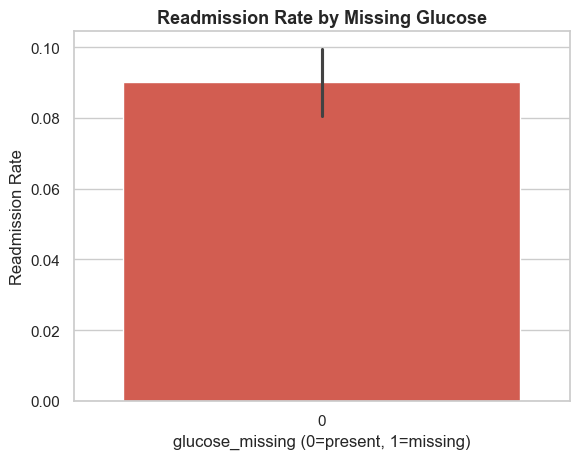

In [44]:
# Create glucose_missing indicator BEFORE imputing
# (captures informational value of the missingness itself)
train_df["glucose_missing"] = train_df["glucose_level_mgdl"].isnull().astype(int)
test_df["glucose_missing"]  = test_df["glucose_level_mgdl"].isnull().astype(int)
print("✅ glucose_missing indicator created")

# Visualize: does missing glucose correlate with readmission?
sns.barplot(x="glucose_missing", y="readmitted_30d", data=train_df, color="#e74c3c")
plt.title("Readmission Rate by Missing Glucose", fontsize=13, fontweight="bold")
plt.xlabel("glucose_missing (0=present, 1=missing)")
plt.ylabel("Readmission Rate")
plt.show()

In [45]:
# Impute missing values using TRAIN medians only (prevent data leakage)
age_median     = train_df["age"].median()
glucose_median = train_df["glucose_level_mgdl"].median()

print(f"Imputation values (from train):")
print(f"  age median:     {age_median}")
print(f"  glucose median: {glucose_median}")

# Apply to both train and test
for df in [train_df, test_df]:
    df["age"].fillna(age_median, inplace=True)
    df["glucose_level_mgdl"].fillna(glucose_median, inplace=True)

print(f"Remaining NaNs in train: {train_df.isnull().sum().sum()}")
print(f"Remaining NaNs in test:  {test_df.isnull().sum().sum()}")

Imputation values (from train):
  age median:     53.0
  glucose median: 103.6
Remaining NaNs in train: 0
Remaining NaNs in test:  0


### 4.6 Encode Categorical Features

In [47]:
print(train_df.columns)

Index(['age', 'gender', 'admission_type', 'discharge_destination',
       'length_of_stay_days', 'charlson_comorbidity_index',
       'prior_admissions_1yr', 'n_medications_discharge', 'glucose_level_mgdl',
       'blood_pressure_systolic', 'sodium_meql', 'creatinine_mgdl',
       'haemoglobin_gdl', 'readmitted_30d', 'admission_month', 'admission_day',
       'admission_weekday', 'glucose_missing', 'ins_Medicaid', 'ins_Medicare',
       'ins_Private', 'ins_Uninsured', 'day_Fri', 'day_Mon', 'day_Sat',
       'day_Sun', 'day_Thu', 'day_Tue', 'day_Wed'],
      dtype='str')


In [49]:
# 1. gender: M=1, F=0 (binary encoding)
train_df["gender"] = (train_df["gender"] == "M").astype(int)
test_df["gender"]  = (test_df["gender"] == "M").astype(int)
print("✅ gender encoded (M=1, F=0)")

# # 2. insurance_type: one-hot encode
# train_ins = pd.get_dummies(train_df["insurance_type"], prefix="ins")
# test_ins  = pd.get_dummies(test_df["insurance_type"], prefix="ins")
# for col in train_ins.columns:  # align columns
#     if col not in test_ins.columns:
#         test_ins[col] = 0
# test_ins = test_ins[train_ins.columns]
# train_df = pd.concat([train_df.drop(columns=["insurance_type"]), train_ins], axis=1)
# test_df  = pd.concat([test_df.drop(columns=["insurance_type"]), test_ins], axis=1)
# print(f"✅ insurance_type one-hot encoded: {list(train_ins.columns)}")

# # 3. discharge_day_of_week: one-hot encode
# train_day = pd.get_dummies(train_df["discharge_day_of_week"], prefix="day")
# test_day  = pd.get_dummies(test_df["discharge_day_of_week"], prefix="day")
# for col in train_day.columns:
#     if col not in test_day.columns:
#         test_day[col] = 0
# test_day = test_day[train_day.columns]
# train_df = pd.concat([train_df.drop(columns=["discharge_day_of_week"]), train_day], axis=1)
# test_df  = pd.concat([test_df.drop(columns=["discharge_day_of_week"]), test_day], axis=1)
# print(f"✅ discharge_day_of_week one-hot encoded: {list(train_day.columns)}")

print(f"Final train shape: {train_df.shape}")
print(f"Final test shape:  {test_df.shape}")

✅ gender encoded (M=1, F=0)
Final train shape: (3800, 29)
Final test shape:  (950, 28)


### 4.7 Separate Features & Target, then Scale

In [50]:
TARGET = "readmitted_30d"

y_full    = train_df[TARGET].values
X_full_df = train_df.drop(columns=[TARGET])
X_test_df = test_df.copy()

# Align column order between train features and test
for col in X_full_df.columns:
    if col not in X_test_df.columns:
        X_test_df[col] = 0
X_test_df = X_test_df[X_full_df.columns]

# Scale numeric features (fit on train ONLY to prevent leakage)
numeric_cols = [
    "age", "admission_type", "discharge_destination",
    "length_of_stay_days", "charlson_comorbidity_index",
    "prior_admissions_1yr", "n_medications_discharge",
    "glucose_level_mgdl", "blood_pressure_systolic",
    "sodium_meql", "creatinine_mgdl", "haemoglobin_gdl",
    "admission_month", "admission_day", "admission_weekday"
]
numeric_cols = [c for c in numeric_cols if c in X_full_df.columns]

scaler = StandardScaler()
X_full_df = X_full_df.copy()
X_test_df = X_test_df.copy()
X_full_df[numeric_cols] = scaler.fit_transform(X_full_df[numeric_cols])
X_test_df[numeric_cols] = scaler.transform(X_test_df[numeric_cols])

print(f"✅ StandardScaler applied to {len(numeric_cols)} numeric features")
print(f"Feature matrix (train): {X_full_df.shape}")
print(f"Feature matrix (test):  {X_test_df.shape}")
print(f"Target: {y_full.shape}, positive ratio: {y_full.mean():.4f}")
print(f"All {len(X_full_df.columns)} features:")
for i, col in enumerate(X_full_df.columns):
    print(f"  {i+1:2d}. {col}")

✅ StandardScaler applied to 15 numeric features
Feature matrix (train): (3800, 28)
Feature matrix (test):  (950, 28)
Target: (3800,), positive ratio: 0.0900
All 28 features:
   1. age
   2. gender
   3. admission_type
   4. discharge_destination
   5. length_of_stay_days
   6. charlson_comorbidity_index
   7. prior_admissions_1yr
   8. n_medications_discharge
   9. glucose_level_mgdl
  10. blood_pressure_systolic
  11. sodium_meql
  12. creatinine_mgdl
  13. haemoglobin_gdl
  14. admission_month
  15. admission_day
  16. admission_weekday
  17. glucose_missing
  18. ins_Medicaid
  19. ins_Medicare
  20. ins_Private
  21. ins_Uninsured
  22. day_Fri
  23. day_Mon
  24. day_Sat
  25. day_Sun
  26. day_Thu
  27. day_Tue
  28. day_Wed


## 5. Train / Validation Split (Stratified)

In [51]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full_df.values, y_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_full
)

print(f"Train: {X_train.shape[0]} samples, positive ratio: {y_train.mean():.4f}")
print(f"Val:   {X_val.shape[0]} samples, positive ratio: {y_val.mean():.4f}")

Train: 3040 samples, positive ratio: 0.0901
Val:   760 samples, positive ratio: 0.0895


## 6. Class Imbalance Mitigation – SMOTE

SMOTE is applied **only to the training split** (never validation/test).
We use three strategies combined:
1. **SMOTE** – synthetic minority oversampling
2. **Class-weighted loss** – penalises misclassification of minority class during training
3. **Threshold tuning** – post-training threshold optimised for F1 score

In [52]:
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)  # minority → 50% of majority
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape[0]} samples, pos ratio: {y_train.mean():.4f}")
print(f"After  SMOTE: {X_train_sm.shape[0]} samples, pos ratio: {y_train_sm.mean():.4f}")

unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {int(u)}: {c} samples")

Before SMOTE: 3040 samples, pos ratio: 0.0901
After  SMOTE: 4149 samples, pos ratio: 0.3333
  Class 0: 2766 samples
  Class 1: 1383 samples


## 7. Prepare PyTorch Datasets

In [53]:
# Cast to float32 to avoid numpy object-array issues with one-hot boolean cols
X_train_t = torch.FloatTensor(X_train_sm.astype(np.float32))
y_train_t = torch.FloatTensor(y_train_sm.astype(np.float32))
X_val_t   = torch.FloatTensor(X_val.astype(np.float32))
y_val_t   = torch.FloatTensor(y_val.astype(np.float32))
X_test_t  = torch.FloatTensor(X_test_df.values.astype(np.float32))

BATCH_SIZE   = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train_t.shape[1]
print(f"Input features: {INPUT_DIM}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Input features: 28
Train batches: 65, Val batches: 12


## 8. Deep Learning Model Architecture

4-layer feedforward neural network:
- Input → Dense(128) → BatchNorm → ReLU → Dropout(0.3)
- → Dense(64)  → BatchNorm → ReLU → Dropout(0.3)
- → Dense(32)  → BatchNorm → ReLU → Dropout(0.2)
- → Dense(16)  → ReLU
- → Dense(1)   → Sigmoid

In [55]:
class ReadmissionNet(nn.Module):
    """
    Multi-layer perceptron for 30-day readmission prediction.
    BatchNorm + Dropout prevent overfitting on the small dataset (3800 samples).
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze()


model = ReadmissionNet(INPUT_DIM)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

ReadmissionNet(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): ReLU()
    (14): Linear(in_features=16, out_features=1, bias=True)
    (15): Sigmoid()
  )
)
Total parameters: 15,041


## 9. Training (Class-Weighted Loss + Early Stopping)

In [57]:
# Compute class weight from SMOTE-ed training data
n_neg      = (y_train_sm == 0).sum()
n_pos      = (y_train_sm == 1).sum()
POS_WEIGHT = float(n_neg / n_pos)
print(f"Positive class weight (for loss): {POS_WEIGHT:.2f}")

# Per-sample BCE so we can apply sample weights manually
criterion = nn.BCELoss(reduction="none")
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=10)

Positive class weight (for loss): 2.00


In [58]:
def train_one_epoch(model, loader, criterion, optimizer, pos_w):
    model.train()
    total_loss, preds, labels = 0, [], []
    for xb, yb in loader:
        optimizer.zero_grad()
        out = model(xb)
        loss_per = criterion(out, yb)
        w    = torch.where(yb == 1, pos_w, 1.0)
        loss = (loss_per * w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds.extend(out.detach().cpu().numpy())
        labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    auc = roc_auc_score(labels, preds) if len(set(labels)) > 1 else 0.0
    return avg_loss, auc


def evaluate_model(model, loader):
    model.eval()
    total_loss, preds, labels = 0, [], []
    bce = nn.BCELoss()
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            total_loss += bce(out, yb).item() * xb.size(0)
            preds.extend(out.cpu().numpy())
            labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    p, l = np.array(preds), np.array(labels)
    auc_roc = roc_auc_score(l, p)          if len(set(labels)) > 1 else 0.0
    auc_pr  = average_precision_score(l, p) if len(set(labels)) > 1 else 0.0
    return avg_loss, auc_roc, auc_pr, p, l

In [61]:
EPOCHS  = 150
PATIENCE = 20

best_auc = 0.0
wait     = 0
hist = {"tl": [], "vl": [], "ta": [], "va": [], "vp": []}

for epoch in range(EPOCHS):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, POS_WEIGHT)
    vl, va, vp, _, _ = evaluate_model(model, val_loader)

    hist["tl"].append(tl); hist["vl"].append(vl)
    hist["ta"].append(ta); hist["va"].append(va); hist["vp"].append(vp)

    scheduler.step(va)

    if va > best_auc:
        best_auc = va
        wait = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        wait += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"TrLoss: {tl:.4f} TrAUC: {ta:.4f} | "
              f"VlLoss: {vl:.4f} VlAUC: {va:.4f} VlPR: {vp:.4f}")

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}. Best AUC-ROC: {best_auc:.4f}")
        break

print(f"✅ Training complete. Best val AUC-ROC: {best_auc:.4f}")

Epoch  10/150 | TrLoss: 0.2386 TrAUC: 0.9781 | VlLoss: 0.2620 VlAUC: 0.9348 VlPR: 0.6776
Epoch  20/150 | TrLoss: 0.1798 TrAUC: 0.9868 | VlLoss: 0.2382 VlAUC: 0.9242 VlPR: 0.6361
Early stopping at epoch 21. Best AUC-ROC: 0.9504
✅ Training complete. Best val AUC-ROC: 0.9504


## 10. Training Curves

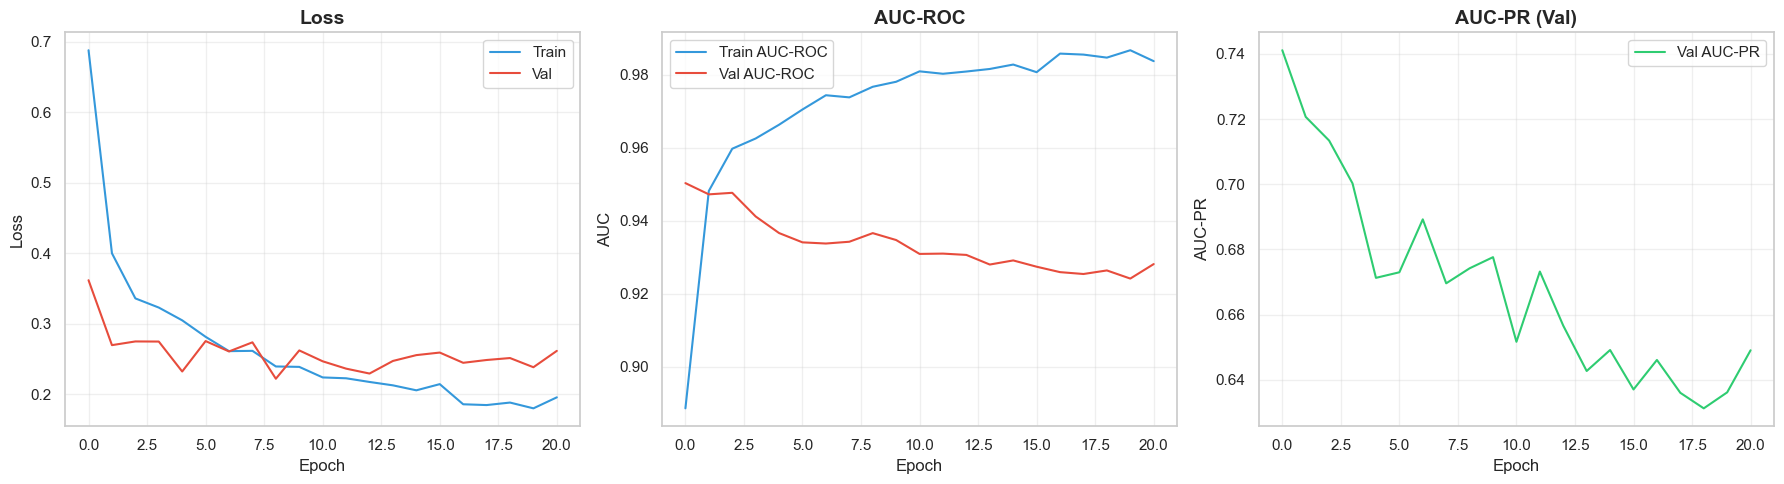

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hist["tl"], label="Train", color="#3498db")
axes[0].plot(hist["vl"], label="Val",   color="#e74c3c")
axes[0].set_title("Loss", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist["ta"], label="Train AUC-ROC", color="#3498db")
axes[1].plot(hist["va"], label="Val AUC-ROC",   color="#e74c3c")
axes[1].set_title("AUC-ROC", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(hist["vp"], label="Val AUC-PR", color="#2ecc71")
axes[2].set_title("AUC-PR (Val)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUC-PR")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Evaluation on Validation Set

In [63]:
# Load best checkpoint
model.load_state_dict(torch.load("best_model.pth"))
_, val_auc_roc, val_auc_pr, val_preds, val_labels = evaluate_model(model, val_loader)

print(f"Val AUC-ROC: {val_auc_roc:.4f}")
print(f"Val AUC-PR:  {val_auc_pr:.4f}")

Val AUC-ROC: 0.9504
Val AUC-PR:  0.7411


Optimal threshold: 0.77
Best F1:           0.6719


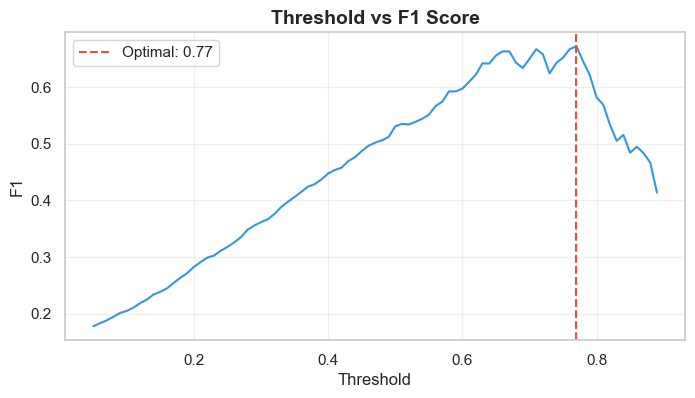

In [64]:
# Find optimal decision threshold by maximising F1 on validation set
thresholds = np.arange(0.05, 0.90, 0.01)
f1s = [f1_score(val_labels, (val_preds >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]

print(f"Optimal threshold: {best_thresh:.2f}")
print(f"Best F1:           {max(f1s):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1s, color="#3498db")
plt.axvline(x=best_thresh, color="#e74c3c", ls="--", label=f"Optimal: {best_thresh:.2f}")
plt.title("Threshold vs F1 Score", fontsize=14, fontweight="bold")
plt.xlabel("Threshold"); plt.ylabel("F1")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [65]:
# Final metrics at optimal threshold
val_binary = (val_preds >= best_thresh).astype(int)

print("=" * 60)
print("FINAL VALIDATION RESULTS")
print("=" * 60)
print(f"Threshold: {best_thresh:.2f}")
print(f"AUC-ROC:   {val_auc_roc:.4f}")
print(f"AUC-PR:    {val_auc_pr:.4f}")
print(f"F1:        {f1_score(val_labels, val_binary):.4f}")
print(f"Precision: {precision_score(val_labels, val_binary):.4f}")
print(f"Recall:    {recall_score(val_labels, val_binary):.4f}")
print()
print(classification_report(val_labels, val_binary, target_names=["Not Readmitted", "Readmitted"]))

FINAL VALIDATION RESULTS
Threshold: 0.77
AUC-ROC:   0.9504
AUC-PR:    0.7411
F1:        0.6719
Precision: 0.7167
Recall:    0.6324

                precision    recall  f1-score   support

Not Readmitted       0.96      0.98      0.97       692
    Readmitted       0.72      0.63      0.67        68

      accuracy                           0.94       760
     macro avg       0.84      0.80      0.82       760
  weighted avg       0.94      0.94      0.94       760



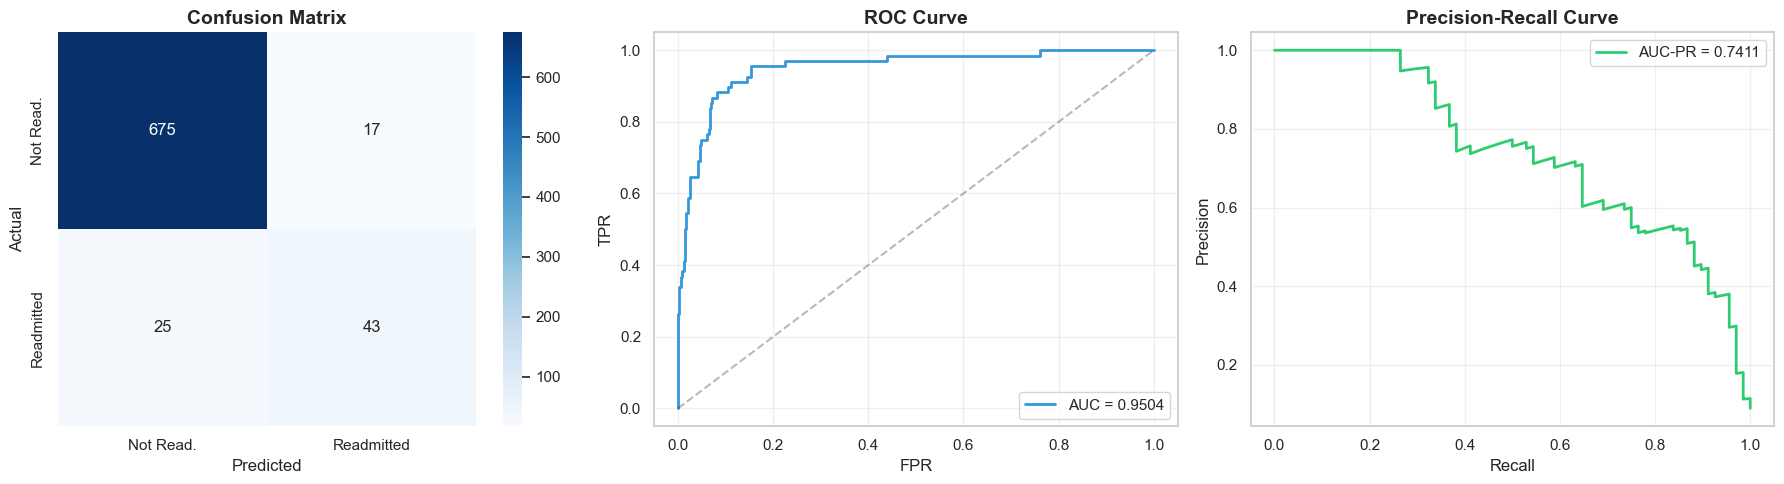

In [66]:
# Confusion Matrix, ROC Curve, Precision-Recall Curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(val_labels, val_binary)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not Read.", "Readmitted"],
            yticklabels=["Not Read.", "Readmitted"])
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

fpr, tpr, _ = roc_curve(val_labels, val_preds)
axes[1].plot(fpr, tpr, color="#3498db", lw=2, label=f"AUC = {val_auc_roc:.4f}")
axes[1].plot([0,1],[0,1], "k--", alpha=0.3)
axes[1].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

prec_v, rec_v, _ = precision_recall_curve(val_labels, val_preds)
axes[2].plot(rec_v, prec_v, color="#2ecc71", lw=2, label=f"AUC-PR = {val_auc_pr:.4f}")
axes[2].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Generate Test Set Predictions

In [68]:
model.eval()
with torch.no_grad():
    test_probs = model(X_test_t).numpy()

test_binary = (test_probs >= best_thresh).astype(int)

print(f"Test samples: {len(test_binary)}")
print(f"Predicted positive: {test_binary.sum()} ({test_binary.mean()*100:.1f}%)")
print(f"Predicted negative: {(1-test_binary).sum()} ({(1-test_binary.mean())*100:.1f}%)")

results = pd.DataFrame({
    "readmitted_30d_prob": test_probs,
    "readmitted_30d_pred": test_binary
})
results.to_csv("test_predictions.csv", index=False)
print("✅ Predictions saved to test_predictions.csv")

Test samples: 950
Predicted positive: 67 (7.1%)
Predicted negative: 883 (92.9%)
✅ Predictions saved to test_predictions.csv


## 13. Pipeline Summary

### Data
- **Source**:  (3,800 rows),  (950 rows)
- **Target**:  — severely imbalanced (~9% positive)

### Preprocessing Steps (in order)
1. Drop 
2. Replace age outlier  → NaN
3. Fix blood pressure unit error (kPa → mmHg for values < 50)
4. Feature-engineer  → , , 
5. Create  indicator (captures informational value of missingness)
6. Median imputation for  and  (train medians applied to both sets)
7. Binary encode  (M=1, F=0)
8. One-hot encode  and 
9.  on numeric features (fit on train only)

### Class Imbalance Mitigation (3 strategies combined)
- **SMOTE** on training split (minority upsampled to 50% of majority)
- **Class-weighted BCE loss** during training
- **Decision threshold tuning** post-training (optimised for F1 on validation set)

### Model
- **Architecture**: 4-layer PyTorch MLP (128 → 64 → 32 → 16 → 1)
- **Regularisation**: BatchNorm + Dropout
- **Optimiser**: Adam (lr=1e-3, weight_decay=1e-4)
- **Scheduler**: ReduceLROnPlateau (patience=10)
- **Early stopping**: patience=20 on validation AUC-ROC

### Evaluation Metrics
- **Primary**: AUC-ROC, AUC-PR, F1-Score, Recall
- ⚠️ Accuracy deliberately excluded — uninformative for 91%/9% imbalance